## Notebook Workflow

1. Configure imports and paths for stage-04 odds-ratio analysis.
2. Run duplication and loss odds-ratio permulation tests.
3. Inspect confidence intervals, hit sets, and result summaries.
4. Export outputs for downstream enrichment and figure generation.

In [ ]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loss

98 species total, 44 foreground, 54 background                                                  
Mean: -0.65, Stddev: 1.53, Count: 5269                                                          


<string>:3: RuntimeWarning: invalid value encountered in log


Optimized triple Gaussian parameters:                                                           
  weight_1: 0.316                                                                               
  mean_1: -2.072                                                                                
  stddev_1: 0.995                                                                               
  weight_2: 0.385                                                                               
  mean_2: -0.381                                                                                
  stddev_2: 0.848                                                                               
  mean_3: 0.495                                                                                 
  stddev_3: 1.513                                                                               
                                                                                                
LAUNCHING PERMUTATION TEST    

  0%|          | 0/10000 [00:00<?, ?it/s]

Permutation counter for MEAN (single Gaussian): 1854                                            
Permutation counter for MEAN 1 (triple Gaussian): 933                                           
Permutation counter for MEAN 2 (triple Gaussian): 2893                                          
Permutation counter for MEAN 3 (triple Gaussian): 1383                                          
                                                                                                
Filtering log odds ratio results df for occupancy >= 50, <= 95 with alternative hypothesis      
'two-tailed' and log odds ratio threshold [-2.75752318  2.71833232]                             
                                                                                                
Filtering for presence of Uloborus_diversus                                                     
                                                                                                
*********************** RESULT

Processing HOGs:   0%|          | 0/385 [00:00<?, ?it/s]

Results files saved to                                                                          
/Users/calvin/orb-selection/results/odds_ratio_test/Results_Mar25/Run1_Loss_LT_50-95_10000x     
                                                                                                
Files include:                                                                                  
	 1. [test]_permutation_results.png: True LORs distribution                                     
		vs. average permuted distribution                                                             
	 2. [test]_permutation_stats_dists.png: Histograms of the                                      
		means, standard deviations, and skews of all 10,000                                           
		permuted LOR distributions                                                                    
	 3. [test]_results_summary.txt: Text file summarizing results                                  
	 4. [test].pkl: Pickle file s

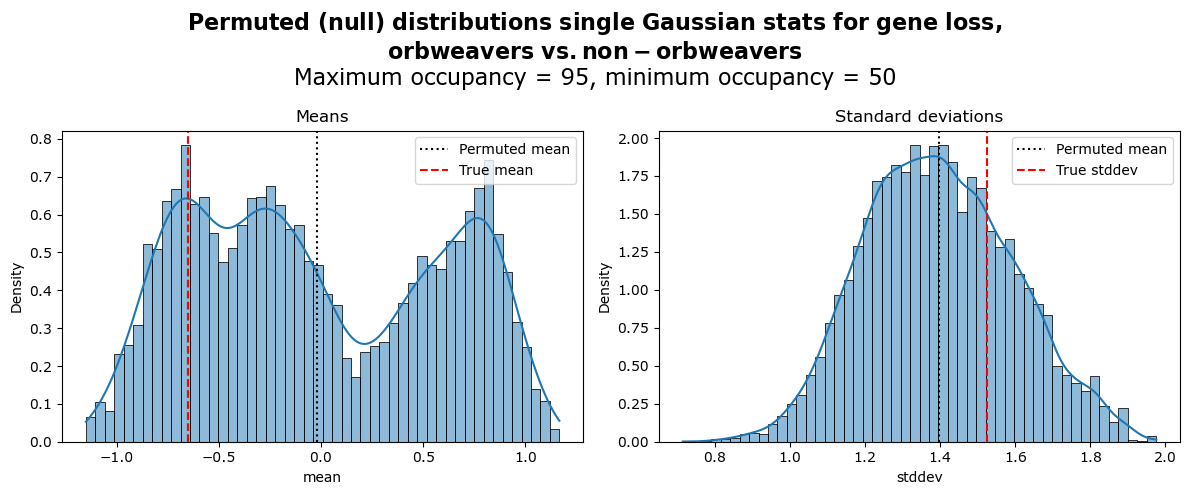

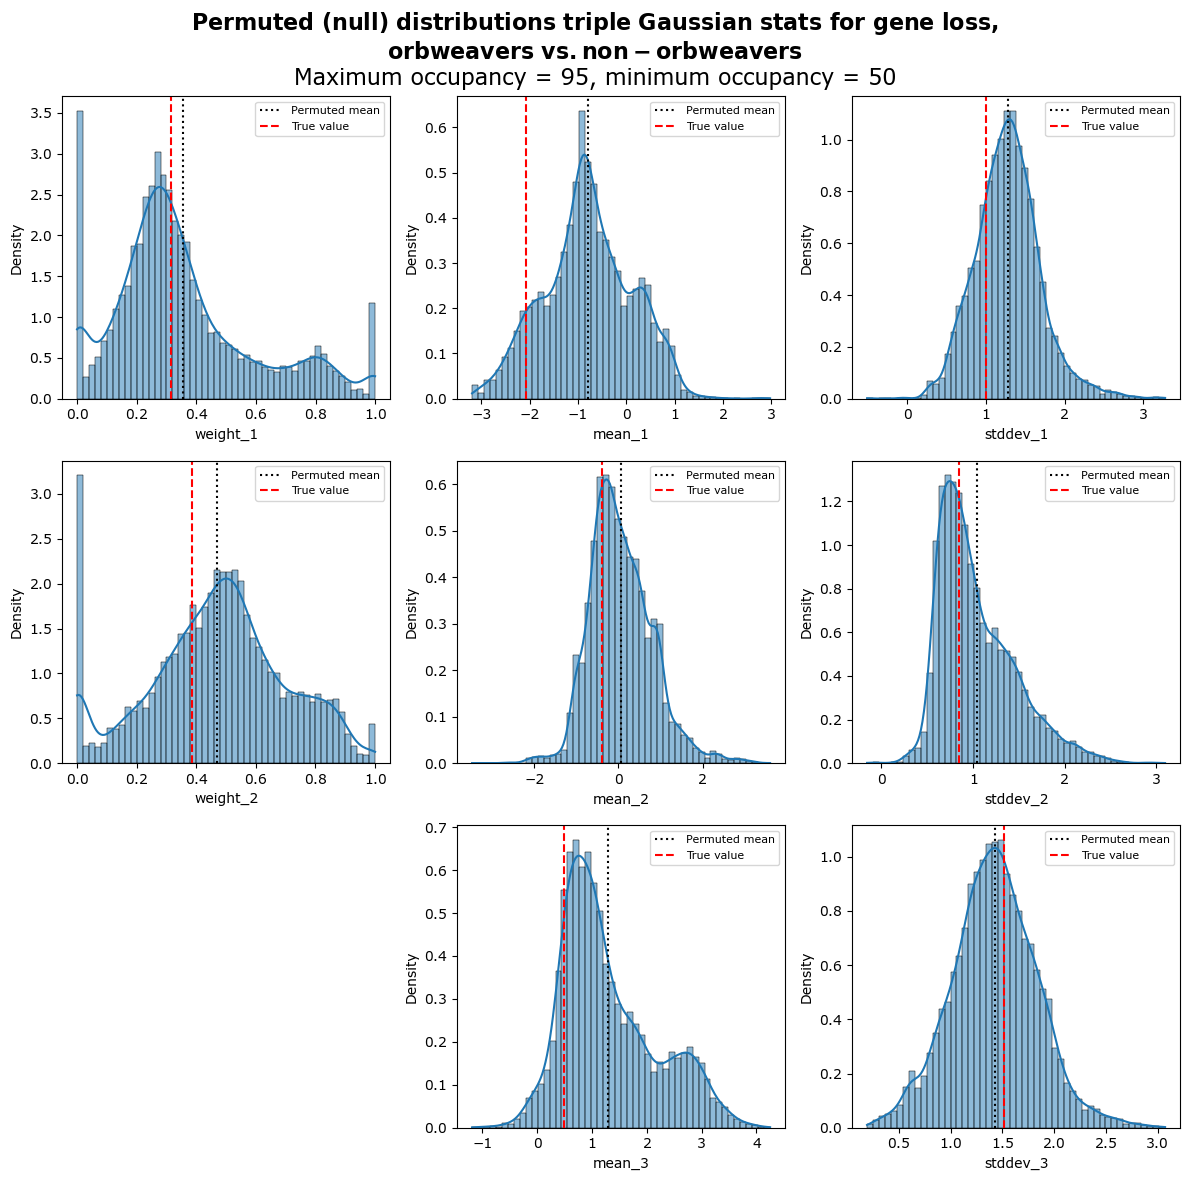

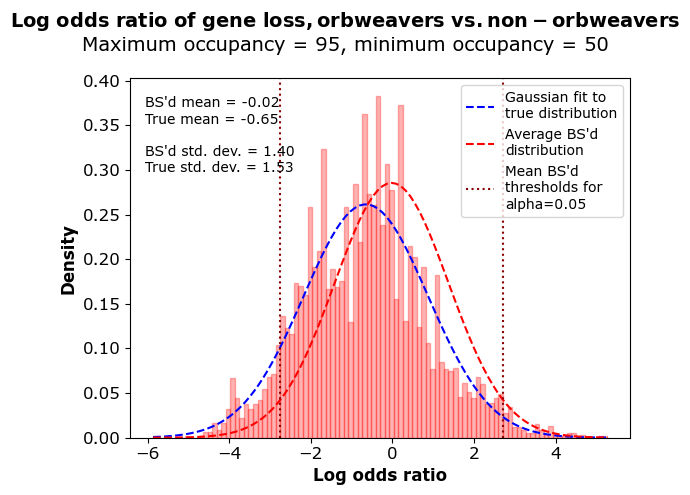

In [ ]:
%autoreload 2
loss_lt_50_95 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=50,
    max_occ=95,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    save_two_tailed_hits=True,
)

## Duplication

98 species total, 44 foreground, 54 background                                                  
Mean: 0.03, Stddev: 0.96, Count: 7875                                                           


/Users/calvin/orb-selection/src/odds_ratio_test.py:279: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Optimized triple Gaussian parameters:                                                           
  weight_1: 0.480                                                                               
  mean_1: -0.032                                                                                
  stddev_1: 0.652                                                                               
  weight_2: 0.520                                                                               
  mean_2: 0.091                                                                                 
  stddev_2: 1.167                                                                               
  mean_3: 0.586                                                                                 
  stddev_3: 0.703                                                                               
                                                                                                
LAUNCHING PERMUTATION TEST    

  0%|          | 0/10000 [00:00<?, ?it/s]

Permutation counter for MEAN (single Gaussian): 3254                                            
Permutation counter for MEAN 1 (triple Gaussian): 1169                                          
Permutation counter for MEAN 2 (triple Gaussian): 3424                                          
Permutation counter for MEAN 3 (triple Gaussian): 6119                                          
                                                                                                
Filtering log odds ratio results df for occupancy >= 50, <= 98 with alternative hypothesis      
'two-tailed' and log odds ratio threshold [-1.81861149  1.81192599]                             
                                                                                                
Filtering for presence of Uloborus_diversus                                                     
                                                                                                
*********************** RESULT

Processing HOGs:   0%|          | 0/352 [00:00<?, ?it/s]

Results files saved to                                                                          
/Users/calvin/orb-selection/results/odds_ratio_test/Results_Mar25/Run2_Dup_RT_50-max_10000x     
                                                                                                
Files include:                                                                                  
	 1. [test]_permutation_results.png: True LORs distribution                                     
		vs. average permuted distribution                                                             
	 2. [test]_permutation_stats_dists.png: Histograms of the                                      
		means, standard deviations, and skews of all 10,000                                           
		permuted LOR distributions                                                                    
	 3. [test]_results_summary.txt: Text file summarizing results                                  
	 4. [test].pkl: Pickle file s

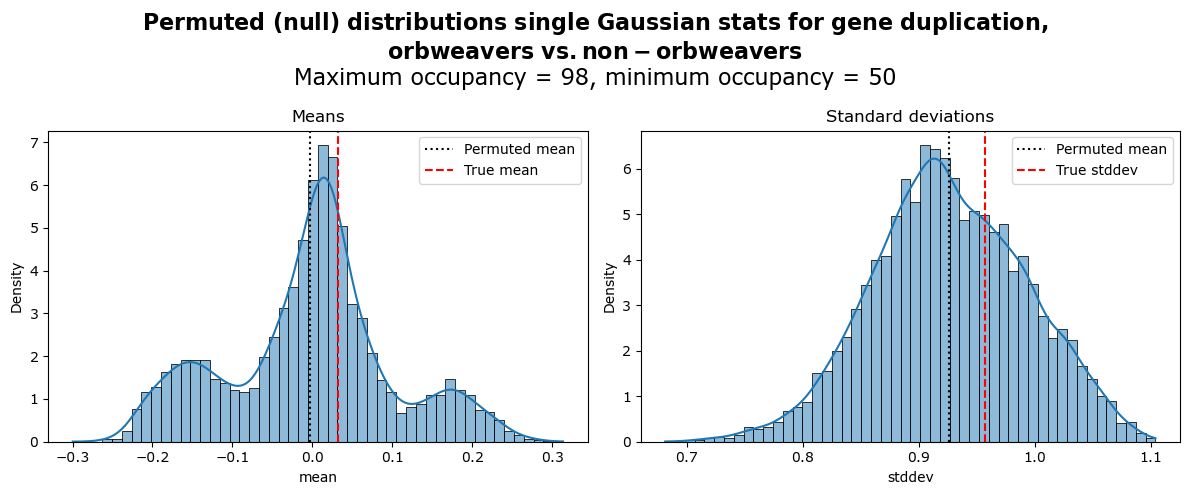

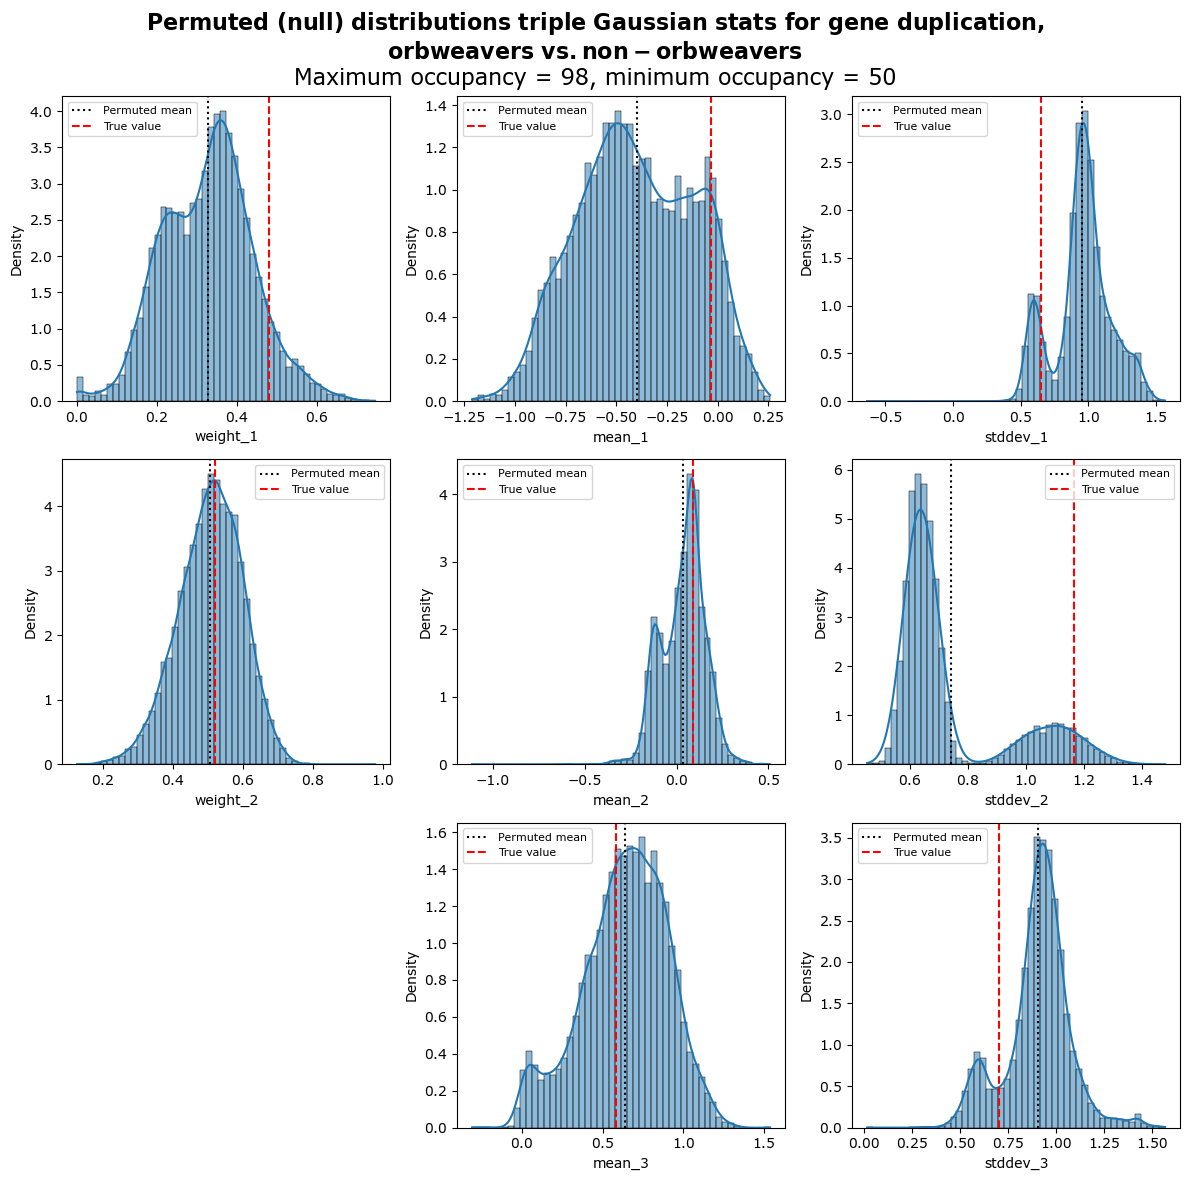

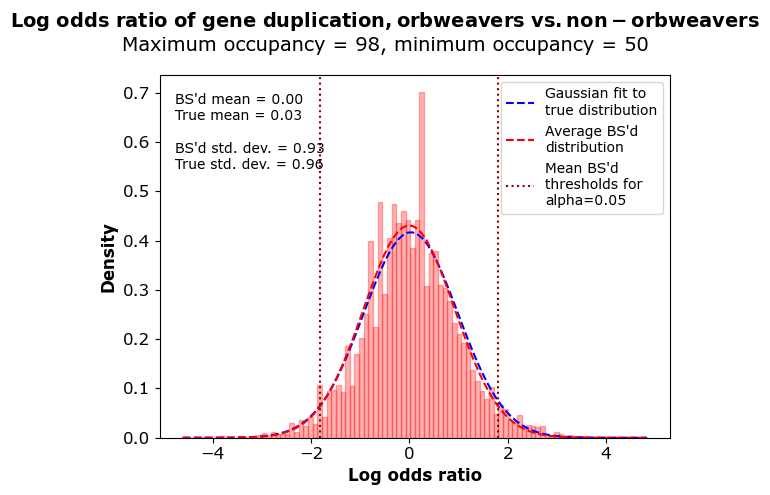

In [4]:
%autoreload 2
dup_rt_50_98 = ort.odds_ratio_test(
    test="duplication",
    occupancy_threshold=50,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    save_two_tailed_hits=True,
)

Save hit lists for GO enrichment

In [21]:
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Mar25")

# Loss results
loss_results = ort.PermutationTestResults.load_from_pickle(f'{ort_dir}/Run1_Loss_LT_50-95_10000x/loss_occ50-95_less.pkl')
loss_df = loss_results.results_fltrd_df
loss_orb = loss_df[loss_df["Log odds ratio"] > 0]
loss_nonorb = loss_df[loss_df["Log odds ratio"] < 0]

# Duplication results
dup_results = ort.PermutationTestResults.load_from_pickle(f'{ort_dir}/Run2_Dup_RT_50-max_10000x/duplication_occ50-98_greater.pkl')
dup_df = dup_results.results_fltrd_df
dup_orb = dup_df[dup_df["Log odds ratio"] > 0]
dup_nonorb = dup_df[dup_df["Log odds ratio"] < 0]

In [34]:
loss_orb_locs_df = convert_hogs_to_locs(loss_orb, os.path.join(repo_root, "data/N5.tsv"))
loss_orb_locs_list = loss_orb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(loss_orb_locs_list)

Processing HOGs:   0%|          | 0/89 [00:00<?, ?it/s]

93

In [32]:
loss_nonorb_locs_df = convert_hogs_to_locs(loss_nonorb, os.path.join(repo_root, "data/N5.tsv"))
loss_nonorb_locs_list = loss_nonorb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(loss_nonorb_locs_list)

Processing HOGs:   0%|          | 0/296 [00:00<?, ?it/s]

295

In [33]:
dup_orb_locs_df = convert_hogs_to_locs(dup_orb, os.path.join(repo_root, "data/N5.tsv"))
dup_orb_locs_list = dup_orb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(dup_orb_locs_list)

Processing HOGs:   0%|          | 0/179 [00:00<?, ?it/s]

176

In [35]:
dup_nonorb_locs_df = convert_hogs_to_locs(dup_nonorb, os.path.join(repo_root, "data/N5.tsv"))
dup_nonorb_locs_list = dup_nonorb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(dup_nonorb_locs_list)

Processing HOGs:   0%|          | 0/173 [00:00<?, ?it/s]

170

In [36]:
list_names = ['loss_orb', 'loss_nonorb'] 
lists = [loss_orb_locs_list, loss_nonorb_locs_list]

for name, lst in zip(list_names, lists):
    filepath = os.path.join(repo_root, f'results/significant_gene_id_lists/odds_ratio_test/loss/{name}.txt')
    with open(filepath, 'w') as f:
        f.write('\n'.join(lst))
    print(f"Wrote {len(lst)} items to {filepath}")

list_names = ['duplication_orb', 'duplication_nonorb']
lists = [dup_orb_locs_list, dup_nonorb_locs_list]

for name, lst in zip(list_names, lists):
    filepath = os.path.join(repo_root, f'results/significant_gene_id_lists/odds_ratio_test/duplication/{name}.txt')
    with open(filepath, 'w') as f:
        f.write('\n'.join(lst))
    print(f"Wrote {len(lst)} items to {filepath}")

Wrote 93 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/odds_ratio_test/loss/loss_orb.txt
Wrote 295 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/odds_ratio_test/loss/loss_nonorb.txt
Wrote 176 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/odds_ratio_test/duplication/duplication_orb.txt
Wrote 170 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/odds_ratio_test/duplication/duplication_nonorb.txt
